# 安装和导入必要的库
Import gymnasium and minigrid libraries. Install minigrid if needed using pip install minigrid. Also import matplotlib for visualization and numpy for array operations.

In [5]:
# 安装和导入必要的库

# 安装 minigrid 库（如果尚未安装）
# !pip install minigrid

# 导入 gymnasium 和 minigrid 库
import gymnasium as gym
import minigrid

# 导入 matplotlib 和 numpy，用于可视化和数组操作
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 创建 MiniGrid 环境
Create a MiniGrid-Empty-16x16-v0 environment using gymnasium.make(). Reset the environment to get the initial observation and render the first frame.

In [67]:
# 创建 MiniGrid 环境
env = gym.make("MiniGrid-Empty-6x6-v0",render_mode="rgb_array")  # 创建环境

obs, info = env.reset()  # 重置环境，获取初始观测值

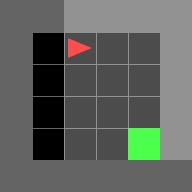

In [75]:



obs, reward, terminated, truncated, info = env.step(0)
env_image = Image.fromarray(env.render())
display(env_image)  # 显示环境图像


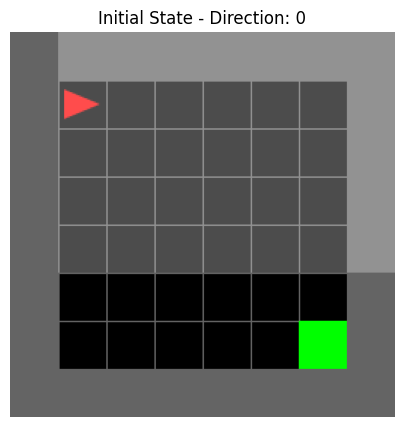


Step 1: Moving R
Current direction: 0
Actions to execute: [2]
New position - Direction: 0

Step 2: Moving R
Current direction: 0
Actions to execute: [2]
New position - Direction: 0

Step 3: Moving U
Current direction: 0
Actions to execute: [0, 2]
New position - Direction: 3

Step 4: Moving U
Current direction: 3
Actions to execute: [2]
New position - Direction: 3

Step 5: Moving L
Current direction: 3
Actions to execute: [0, 2]
New position - Direction: 2


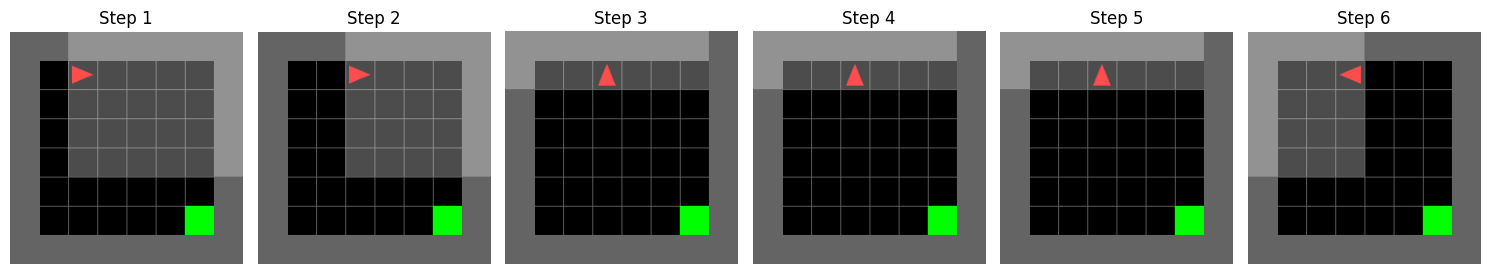

In [77]:
def direction_to_action(env, direction_char):
    """
    将方向字符(L/R/U/D)转换为MiniGrid的动作序列
    
    Args:
        env: MiniGrid环境实例
        direction_char: 'L', 'R', 'U', 'D' 中的一个
        
    Returns:
        list: 需要执行的动作序列 [turn_action(s), forward_action]
    """
    # 获取当前朝向
    current_direction = env.unwrapped.agent_dir
    
    # 方向映射: U=3(上), L=2(左), D=1(下), R=0(右)
    direction_map = {
        'U': 3,
        'L': 2,
        'D': 1,
        'R': 0
    }
    
    target_direction = direction_map.get(direction_char.upper())
    if target_direction is None:
        raise ValueError(f"Invalid direction: {direction_char}. Use L/R/U/D")
    
    # 计算需要转向的次数
    turn_diff = (target_direction - current_direction) % 4
    
    actions = []
    
    # 根据转向差异添加转向动作
    if turn_diff == 1:  # 右转90度
        actions.append(1)  # turn right
    elif turn_diff == 2:  # 转180度
        actions.append(1)  # turn right
        actions.append(1)  # turn right
    elif turn_diff == 3:  # 左转90度
        actions.append(0)  # turn left
    # turn_diff == 0: 不需要转向
    
    # 添加前进动作
    actions.append(2)  # forward
    
    return actions


def execute_direction_path(env, path_string, render=True):
    """
    执行由方向字符串表示的路径
    
    Args:
        env: MiniGrid环境实例
        path_string: 逗号分隔的方向字符串，如 "R,R,U,L"
        render: 是否显示每一步
        
    Returns:
        list: 每一步的结果 (obs, reward, terminated, truncated, info)
    """
    directions = [d.strip() for d in path_string.split(',')]
    results = []
    images = []
    
    for i, direction in enumerate(directions):
        print(f"\nStep {i+1}: Moving {direction}")
        print(f"Current direction: {env.unwrapped.agent_dir}")
        
        # 获取该方向的动作序列
        actions = direction_to_action(env, direction)
        print(f"Actions to execute: {actions}")
        
        # 执行所有动作
        for action in actions:
            obs, reward, terminated, truncated, info = env.step(action)
            
            if render:
                img = env.render()
                images.append(img)
            
            if terminated or truncated:
                print(f"Episode ended! Reward: {reward}")
                results.append((obs, reward, terminated, truncated, info))
                return results, images
        
        # 保存最后一个动作的结果
        results.append((obs, reward, terminated, truncated, info))
        print(f"New position - Direction: {obs['direction']}")
    
    return results, images


# 使用示例
import gymnasium as gym
import matplotlib.pyplot as plt
from PIL import Image

# 创建环境
env = gym.make('MiniGrid-Empty-8x8-v0', render_mode='rgb_array')
obs, info = env.reset()

# 显示初始状态
plt.figure(figsize=(5, 5))
plt.imshow(env.render())
plt.title(f"Initial State - Direction: {obs['direction']}")
plt.axis('off')
plt.show()

# 执行路径
path = "R,R,U,U,L"
results, images = execute_direction_path(env, path, render=True)

# 显示执行过程
fig, axes = plt.subplots(1, min(len(images), 6), figsize=(15, 3))
if len(images) == 1:
    axes = [axes]
    
for idx, img in enumerate(images[:6]):
    axes[idx].imshow(img)
    axes[idx].set_title(f"Step {idx+1}")
    axes[idx].axis('off')
    
plt.tight_layout()
plt.show()

env.close()

{'image': array([[[2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0]],
 
        [[2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0]],
 
        [[2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0]],
 
        [[2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [1, 0, 0]],
 
        [[2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [1, 0, 0]],
 
        [[2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [1, 0, 0]],
 
        [[2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [2, 5, 0],
         [1, 

In [21]:
env.__dir__()

['_saved_kwargs',
 'env',
 '_action_space',
 '_observation_space',
 '_metadata',
 '_cached_spec',
 '_has_reset',
 '_disable_render_order_enforcing',
 '__module__',
 '__doc__',
 '__init__',
 'step',
 'reset',
 'render',
 'has_reset',
 'spec',
 '__orig_bases__',
 '__parameters__',
 'close',
 'np_random_seed',
 'unwrapped',
 'wrapper_spec',
 'has_wrapper_attr',
 'get_wrapper_attr',
 'set_wrapper_attr',
 '__str__',
 '__repr__',
 'class_name',
 'action_space',
 'observation_space',
 'metadata',
 'render_mode',
 'np_random',
 '_np_random',
 '__annotations__',
 '_np_random_seed',
 '__enter__',
 '__exit__',
 '__dict__',
 '__weakref__',
 '__slots__',
 '_is_protocol',
 '__class_getitem__',
 '__init_subclass__',
 '__new__',
 '__hash__',
 '__getattribute__',
 '__setattr__',
 '__delattr__',
 '__lt__',
 '__le__',
 '__eq__',
 '__ne__',
 '__gt__',
 '__ge__',
 '__reduce_ex__',
 '__reduce__',
 '__subclasshook__',
 '__format__',
 '__sizeof__',
 '__dir__',
 '__class__']

# 环境基本信息查看
Print the observation space, action space, and available actions. Display the action meanings (left=0, right=1, forward=2, etc.) and explain what each action does in MiniGrid.

In [15]:
# 环境基本信息查看

# 打印观察空间和动作空间
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

# 定义动作含义
action_meanings = {
    0: "left - Turn left",
    1: "right - Turn right",
    2: "forward - Move forward",
    3: "pickup - Unused",
    4: "drop - Unused",
    5: "toggle - Unused",
    6: "done - Unused"
}

# 打印动作含义
print("\nAvailable Actions:")
for action, meaning in action_meanings.items():
    print(f"{action}: {meaning}")

Observation Space: Dict('direction': Discrete(4), 'image': Box(0, 255, (7, 7, 3), uint8), 'mission': MissionSpace(<function EmptyEnv._gen_mission at 0x7f60f8a70160>, None))
Action Space: Discrete(7)

Available Actions:
0: left - Turn left
1: right - Turn right
2: forward - Move forward
3: pickup - Unused
4: drop - Unused
5: toggle - Unused
6: done - Unused


# 执行随机动作并可视化
Execute 10-20 random actions using env.action_space.sample(). For each step, render the frame and display it using matplotlib. Show the agent's position, direction, and cumulative reward.

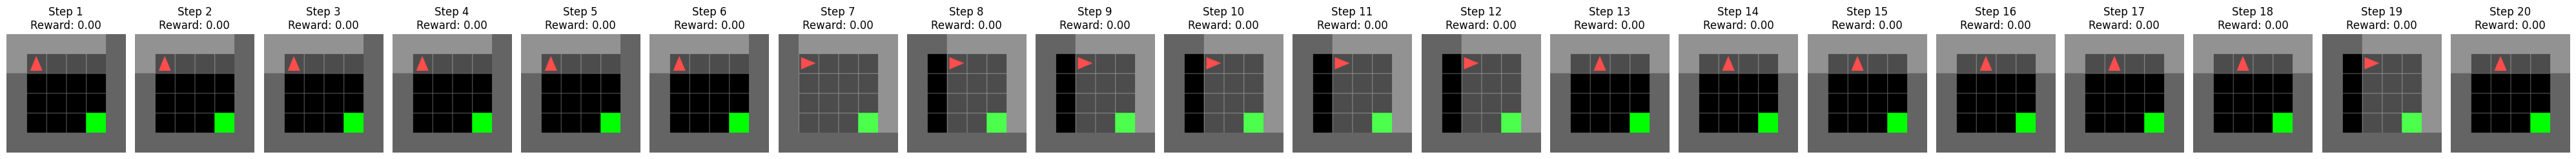

In [16]:
# 执行随机动作并可视化

# 初始化变量
num_steps = 20  # 执行的随机动作数量
cumulative_reward = 0  # 累计奖励

# 创建一个图形窗口
fig, ax = plt.subplots(1, num_steps, figsize=(num_steps * 2, 4))

# 执行随机动作
for step in range(num_steps):
    # 随机采样一个动作
    action = env.action_space.sample()
    
    # 执行动作
    obs, reward, terminated, truncated, info = env.step(action)
    
    # 累计奖励
    cumulative_reward += reward
    
    # 渲染当前帧
    frame = env.render()
    
    # 显示当前帧
    ax[step].imshow(frame)
    ax[step].axis("off")
    ax[step].set_title(f"Step {step + 1}\nReward: {cumulative_reward:.2f}")
    
    # 如果环境终止，提前退出
    if terminated or truncated:
        break

# 调整布局并显示图像
plt.tight_layout()
plt.show()

# 测试特定动作序列
Test a specific sequence of actions (e.g., forward, forward, right, forward) to demonstrate controlled movement. Visualize each step and explain how the agent moves in the grid.

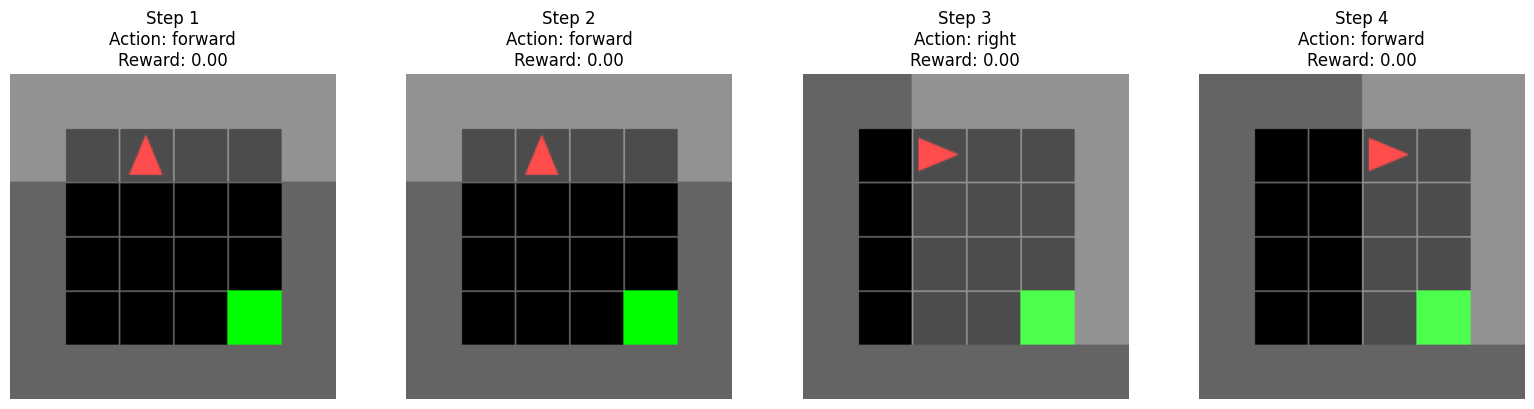

In [17]:
# 测试特定动作序列

# 定义特定的动作序列
action_sequence = [2, 2, 1, 2]  # forward, forward, right, forward

# 初始化变量
cumulative_reward = 0  # 累计奖励

# 创建一个图形窗口
fig, ax = plt.subplots(1, len(action_sequence), figsize=(len(action_sequence) * 4, 4))

# 执行动作序列
for step, action in enumerate(action_sequence):
    # 执行动作
    obs, reward, terminated, truncated, info = env.step(action)
    
    # 累计奖励
    cumulative_reward += reward
    
    # 渲染当前帧
    frame = env.render()
    
    # 显示当前帧
    ax[step].imshow(frame)
    ax[step].axis("off")
    ax[step].set_title(f"Step {step + 1}\nAction: {action_meanings[action].split(' - ')[0]}\nReward: {cumulative_reward:.2f}")
    
    # 如果环境终止，提前退出
    if terminated or truncated:
        break

# 调整布局并显示图像
plt.tight_layout()
plt.show()

# 可视化多个环境状态
Create a grid of subplots showing multiple states from a complete episode. Display 6-9 key frames in a 2x3 or 3x3 grid to show the agent's trajectory through the environment.

In [ ]:
# 可视化多个环境状态

# 定义一个函数，用于从完整的回合中采样关键帧
def visualize_episode(env, num_frames=6):
    """
    可视化一个完整回合中的多个关键帧。
    
    Args:
        env: MiniGrid 环境实例
        num_frames: 要显示的关键帧数量
    """
    obs, info = env.reset()  # 重置环境
    frames = []  # 存储关键帧
    actions = []  # 存储动作
    rewards = []  # 存储奖励
    cumulative_reward = 0  # 累计奖励

    # 执行一个完整回合
    while len(frames) < num_frames:
        # 随机采样一个动作
        action = env.action_space.sample()
        
        # 执行动作
        obs, reward, terminated, truncated, info = env.step(action)
        
        # 累计奖励
        cumulative_reward += reward
        
        # 渲染当前帧
        frame = env.render()
        
        # 存储帧、动作和奖励
        frames.append(frame)
        actions.append(action)
        rewards.append(cumulative_reward)
        
        # 如果环境终止，提前退出
        if terminated or truncated:
            break

    # 可视化关键帧
    num_rows = int(np.ceil(num_frames / 3))  # 计算行数
    fig, axes = plt.subplots(num_rows, 3, figsize=(15, num_rows * 5))
    axes = axes.flatten()

    for i in range(num_frames):
        if i < len(frames):
            axes[i].imshow(frames[i])
            axes[i].axis("off")
            axes[i].set_title(f"Step {i + 1}\nAction: {action_meanings[actions[i]].split(' - ')[0]}\nReward: {rewards[i]:.2f}")
        else:
            axes[i].axis("off")  # 隐藏多余的子图

    plt.tight_layout()
    plt.show()

# 调用函数，显示多个关键帧
visualize_episode(env, num_frames=9)